In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib
from pathlib import Path
from churn_prediction.paths import SRC_DIR, PROCESSED_DIR, INTERIM_NOTEBOOK_DIR, RAW_DIR

In [3]:
order_data = pd.read_csv(RAW_DIR / "olist_orders_dataset.csv")

In [4]:
# Thông tin tổng quan về các cột
order_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [12]:
# Kiểm tra giá trị khuyết
missing = order_data.isnull().sum()
missing_pct = 100 * missing / len(order_data)
missing_df = pd.DataFrame({'Số lượng thiếu': missing, 'Tỷ lệ %': missing_pct})
missing_df[missing_df['Số lượng thiếu'] > 0].sort_values('Số lượng thiếu', ascending=False)

,Số lượng thiếu,Tỷ lệ %
order_delivered_customer_date,2965,2.981668
order_delivered_carrier_date,1783,1.793023
order_approved_at,160,0.160899


### **Nhận xét:**  
##### - Các cột `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date` có giá trị khuyết, chủ yếu ở các đơn hàng chưa hoàn tất.
##### - Sẽ xử lý khi tính toán các chỉ số thời gian (chỉ lấy đơn đã giao).

In [5]:
# Chuyển đổi cột thời gian

# %%
time_cols = ['order_purchase_timestamp', 'order_approved_at', 
             'order_delivered_carrier_date', 'order_delivered_customer_date', 
             'order_estimated_delivery_date']

for col in time_cols:
    order_data[col] = pd.to_datetime(order_data[col], errors='coerce')
    print(f"{col}: {order_data[col].isna().sum()} giá trị thiếu sau chuyển đổi")

order_purchase_timestamp: 0 giá trị thiếu sau chuyển đổi
order_approved_at: 160 giá trị thiếu sau chuyển đổi
order_delivered_carrier_date: 1783 giá trị thiếu sau chuyển đổi
order_delivered_customer_date: 2965 giá trị thiếu sau chuyển đổi
order_estimated_delivery_date: 0 giá trị thiếu sau chuyển đổi


In [13]:
#  Tạo các đặc trưng mới

# Chỉ tính cho đơn hàng đã giao
delivered = order_data[order_data['order_status'] == 'delivered'].copy()

# Thời gian từ đặt hàng đến phê duyệt (giờ)
delivered['approval_hours'] = (delivered['order_approved_at'] - delivered['order_purchase_timestamp']).dt.total_seconds() / 3600

# Thời gian vận chuyển (carrier → customer) (giờ)
delivered['carrier_to_customer_hours'] = (delivered['order_delivered_customer_date'] - delivered['order_delivered_carrier_date']).dt.total_seconds() / 3600

# Tổng thời gian giao hàng (giờ)
delivered['total_delivery_hours'] = (delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']).dt.total_seconds() / 3600

# Độ trễ so với dự kiến (ngày)
delivered['delivery_delay_days'] = (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date']).dt.days

print("Đã tạo xong các đặc trưng thời gian")


Đã tạo xong các đặc trưng thời gian


  order_status  Số lượng  Tỷ lệ (%)
0    delivered     96478  97.020344
1      shipped      1107   1.113223
2     canceled       625   0.628513
3  unavailable       609   0.612423
4     invoiced       314   0.315765
5   processing       301   0.302692
6      created         5   0.005028
7     approved         2   0.002011


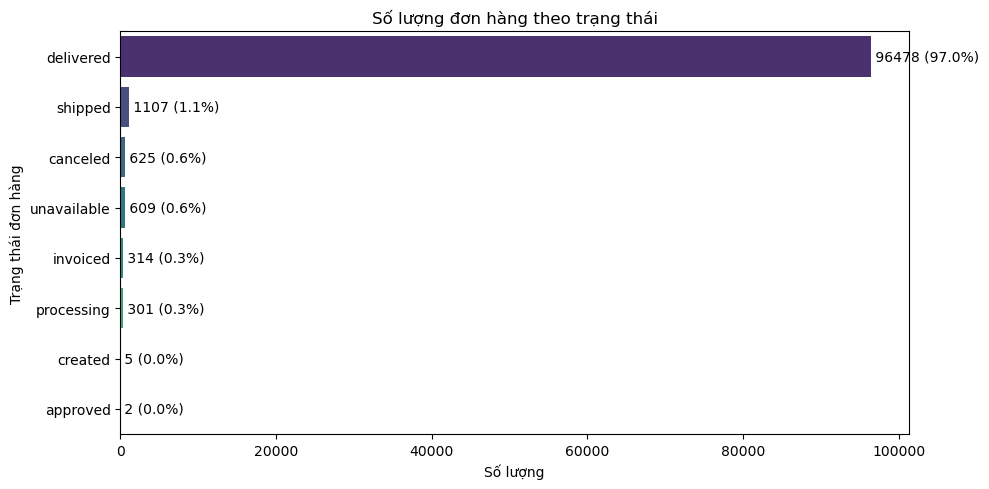

In [11]:
# Phân tích trạng thái đơn hàng

# Tạo dữ liệu
status_counts = order_data['order_status'].value_counts()
status_pct = 100 * status_counts / len(order_data)

status_df = pd.DataFrame({
    'order_status': status_counts.index,
    'Số lượng': status_counts.values,
    'Tỷ lệ (%)': status_pct.values
})

# Hiển thị bảng
print(status_df)

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))

sns.barplot(
    data=status_df,
    x='Số lượng',
    y='order_status',
    hue='order_status',
    palette='viridis',
    legend=False
)

plt.title('Số lượng đơn hàng theo trạng thái')
plt.xlabel('Số lượng')
plt.ylabel('Trạng thái đơn hàng')

# Thêm label 
for i, v in enumerate(status_df['Số lượng']):
    plt.text(v, i, f' {v} ({status_df["Tỷ lệ (%)"][i]:.1f}%)', va='center')

plt.tight_layout()
plt.show()


### **Nhận xét:**  
##### - Hơn 97% đơn hàng được giao thành công (`delivered`).  
##### - Các trạng thái khác chiếm tỷ lệ rất nhỏ (< 3%).

In [14]:
# Trích xuất thành phần thời gian
order_data['purchase_year'] = order_data['order_purchase_timestamp'].dt.year
order_data['purchase_month'] = order_data['order_purchase_timestamp'].dt.month
order_data['purchase_dayofweek'] = order_data['order_purchase_timestamp'].dt.dayofweek   # 0=Mon, 6=Sun
order_data['purchase_hour'] = order_data['order_purchase_timestamp'].dt.hour

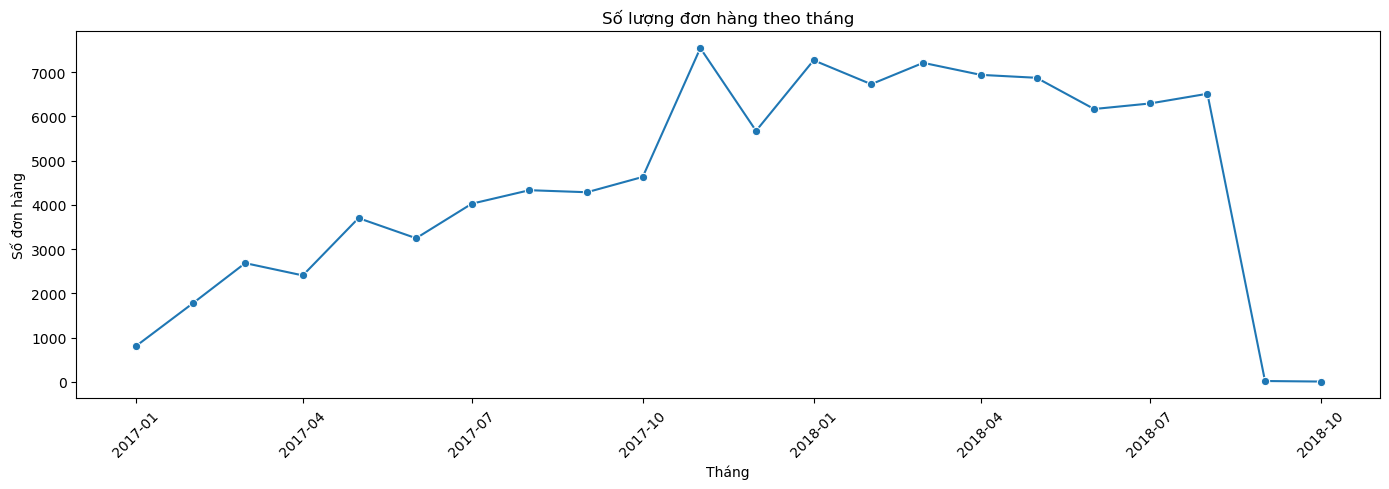

In [16]:
# Đơn hàng theo tháng (chỉ 2017-2018)
monthly = order_data[order_data['purchase_year'].isin([2017,2018])].groupby(['purchase_year','purchase_month']).size().reset_index(name='count')
monthly['date'] = pd.to_datetime({
    'year': monthly['purchase_year'],
    'month': monthly['purchase_month'],
    'day': 1
})

plt.figure(figsize=(14,5))
sns.lineplot(data=monthly, x='date', y='count', marker='o')
plt.title('Số lượng đơn hàng theo tháng')
plt.xlabel('Tháng')
plt.ylabel('Số đơn hàng')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

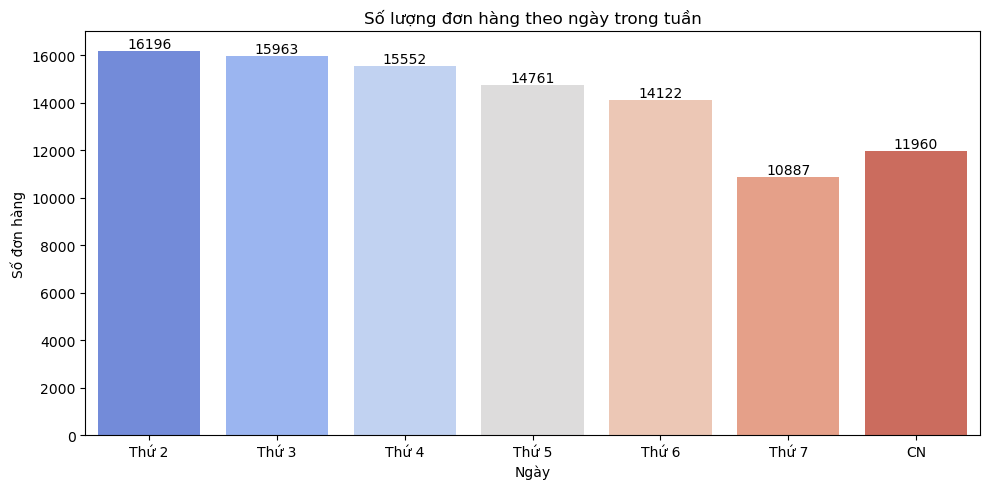

In [23]:
# Đếm theo thứ trong tuần (0=Thứ 2, ..., 6=CN)
weekday_order = order_data['purchase_dayofweek'].value_counts().sort_index()

# Map label đúng thứ tự
weekday_map = {
    0: 'Thứ 2', 1: 'Thứ 3', 2: 'Thứ 4',
    3: 'Thứ 5', 4: 'Thứ 6', 5: 'Thứ 7', 6: 'CN'
}

weekday_df = weekday_order.reset_index()
weekday_df.columns = ['dayofweek', 'Số đơn']
weekday_df['Ngày'] = weekday_df['dayofweek'].map(weekday_map)

# Vẽ biểu đồ
plt.figure(figsize=(10,5))

sns.barplot(
    data=weekday_df,
    x='Ngày',
    y='Số đơn',
    hue='Ngày',
    palette='coolwarm',
    legend=False
)

plt.title('Số lượng đơn hàng theo ngày trong tuần')
plt.xlabel('Ngày')
plt.ylabel('Số đơn hàng')


for i, v in enumerate(weekday_df['Số đơn']):
    plt.text(i, v, f'{v}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

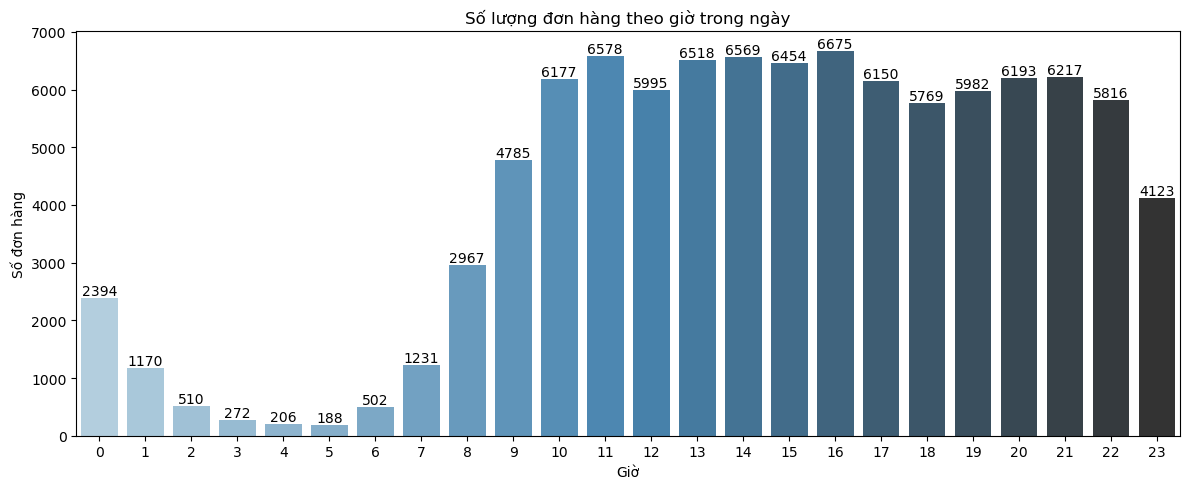

In [27]:
# Theo giờ trong ngày
hourly = order_data['purchase_hour'].value_counts().sort_index()

plt.figure(figsize=(12,5))
sns.barplot(x=hourly.index, y=hourly.values,hue=hourly.index, palette='Blues_d', legend=False)
plt.title('Số lượng đơn hàng theo giờ trong ngày')
plt.xlabel('Giờ')
plt.ylabel('Số đơn hàng')
plt.xticks(range(0,24))
for i, v in enumerate(hourly.values):
    plt.text(i, v, f'{v}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### **Nhận xét:**  
#### - Đơn hàng tăng dần theo thời gian, cao điểm cuối năm (tháng 11,12).  
#### - Đặt nhiều nhất vào các ngày trong tuần (Thứ 2 - Thứ 6), ít hơn cuối tuần.  
#### - Giờ cao điểm: 10h – 22h, đặc biệt 14h – 17h.

In [31]:
# Thời gian xử lý và vận chuyển (chỉ đơn đã giao)
# Thống kê mô tả
stats = delivered[['approval_hours', 'carrier_to_customer_hours', 'total_delivery_hours']].describe()
stats

,approval_hours,carrier_to_customer_hours,total_delivery_hours
count,96464.000000,96469.000000,96470.000000
mean,10.276767,223.927129,301.397210
std,20.535419,210.238168,229.107753
min,0.000000,-386.308056,12.801944
25%,0.215278,98.401111,162.388889
50%,0.343333,170.394444,245.219444
75%,14.514583,288.687500,377.284375
max,741.443611,4924.583333,5031.086667


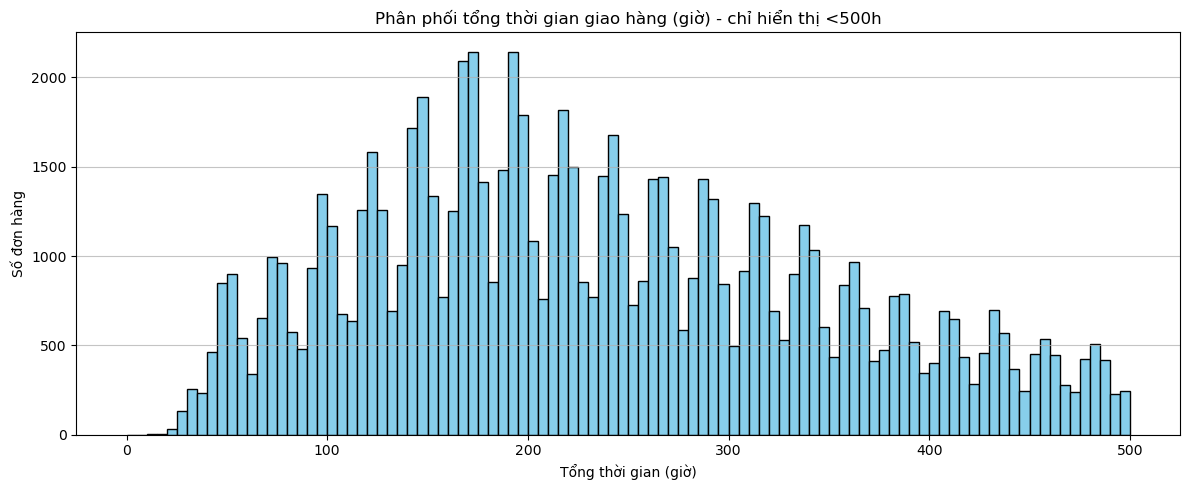

In [29]:
# Vẽ histogram cho total_delivery_hours (giới hạn 500 giờ)
plt.figure(figsize=(12,5))
plt.hist(delivered['total_delivery_hours'].dropna(), bins=100, range=(0,500), color='skyblue', edgecolor='black')
plt.title('Phân phối tổng thời gian giao hàng (giờ) - chỉ hiển thị <500h')
plt.xlabel('Tổng thời gian (giờ)')
plt.ylabel('Số đơn hàng')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

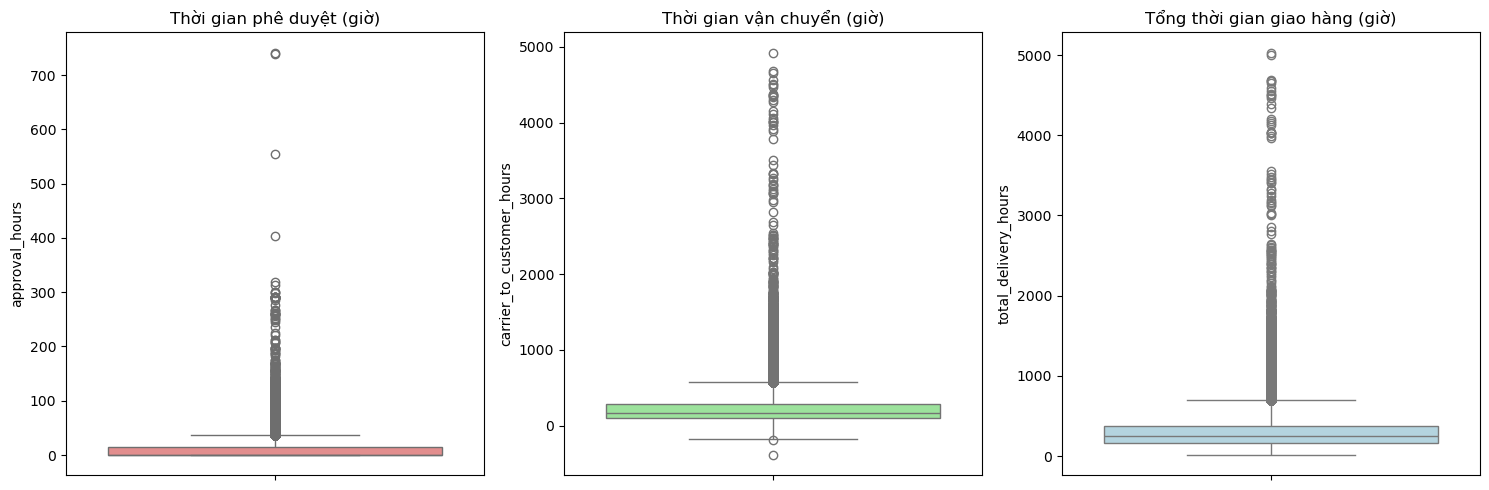

In [30]:
# Boxplot so sánh các giai đoạn
fig, axes = plt.subplots(1, 3, figsize=(15,5))
sns.boxplot(y=delivered['approval_hours'].dropna(), ax=axes[0], color='lightcoral')
axes[0].set_title('Thời gian phê duyệt (giờ)')
sns.boxplot(y=delivered['carrier_to_customer_hours'].dropna(), ax=axes[1], color='lightgreen')
axes[1].set_title('Thời gian vận chuyển (giờ)')
sns.boxplot(y=delivered['total_delivery_hours'].dropna(), ax=axes[2], color='lightblue')
axes[2].set_title('Tổng thời gian giao hàng (giờ)')
plt.tight_layout()
plt.show()

### **Nhận xét:**  
#### - Thời gian phê duyệt trung bình ~5,7 giờ, nhưng có nhiều outlier (có đơn phê duyệt rất lâu).  
#### - Vận chuyển trung bình ~5,4 ngày, tổng thời gian ~7,3 ngày.  
#### - Các boxplot cho thấy sự phân tán lớn, đặc biệt ở thời gian vận chuyển.

Thống kê độ trễ (ngày):
count    96470.000000
mean       -11.875889
std         10.182105
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64


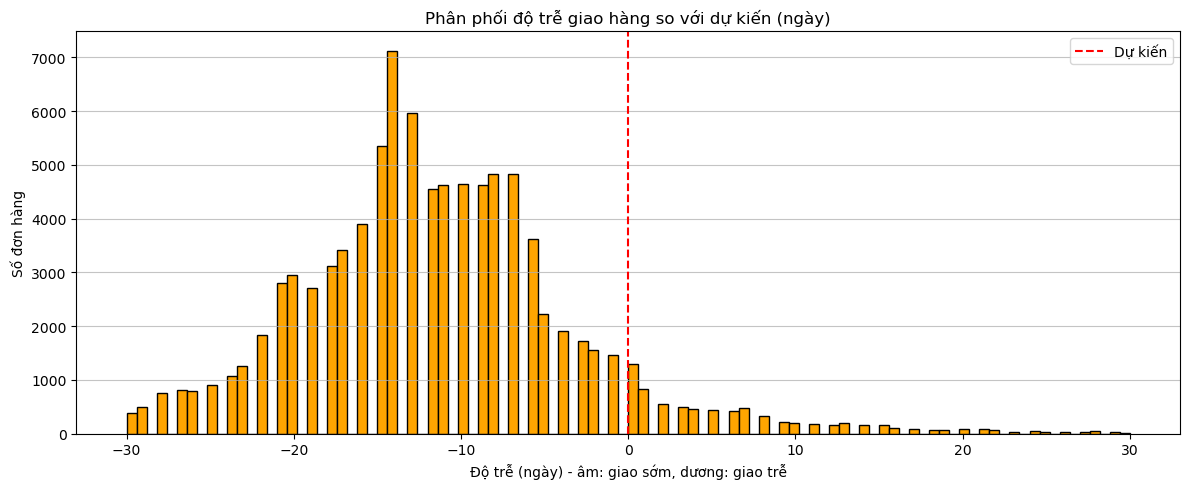

Giao trễ: 6.77%
Giao sớm: 91.89%
Đúng hạn: 1.34%


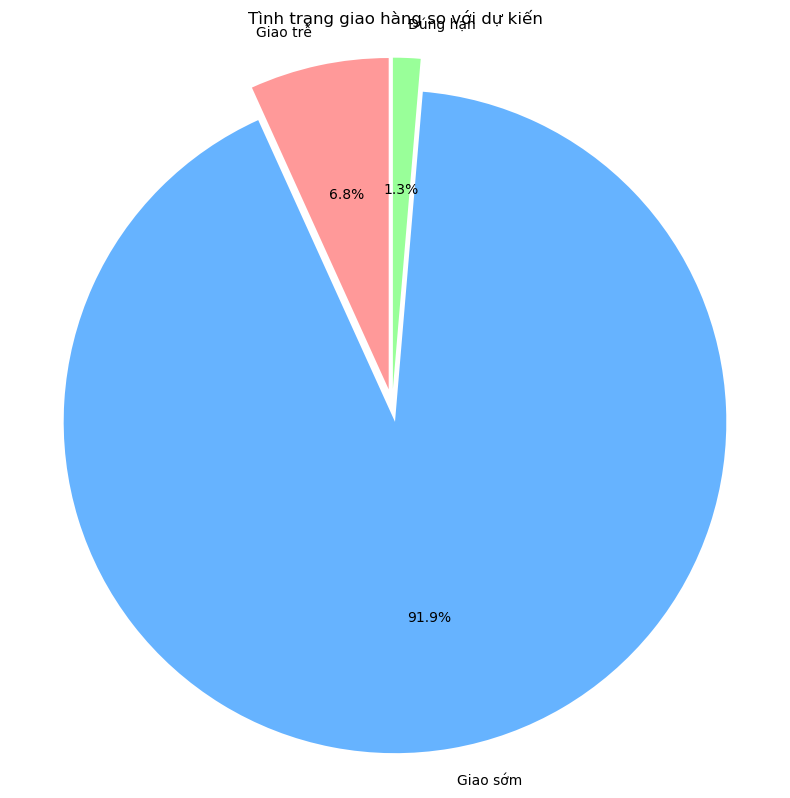

In [32]:
# Phân tích độ trễ so với dự kiến
delay = delivered['delivery_delay_days'].dropna()
print("Thống kê độ trễ (ngày):")
print(delay.describe())
# Vẽ histogram với khoảng -30 đến 30 ngày
plt.figure(figsize=(12,5))
plt.hist(delay, bins=100, range=(-30,30), color='orange', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--', label='Dự kiến')
plt.title('Phân phối độ trễ giao hàng so với dự kiến (ngày)')
plt.xlabel('Độ trễ (ngày) - âm: giao sớm, dương: giao trễ')
plt.ylabel('Số đơn hàng')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# Tính tỷ lệ giao trễ / sớm / đúng hạn
late = (delay > 0).sum()
early = (delay < 0).sum()
on_time = (delay == 0).sum()
total = len(delay)

print(f"Giao trễ: {late/total*100:.2f}%")
print(f"Giao sớm: {early/total*100:.2f}%")
print(f"Đúng hạn: {on_time/total*100:.2f}%")
# Biểu đồ tròn
labels = ['Giao trễ', 'Giao sớm', 'Đúng hạn']
sizes = [late, early, on_time]
colors = ['#ff9999','#66b3ff','#99ff99']
explode = (0.05, 0.05, 0.05)

plt.figure(figsize=(8,8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Tình trạng giao hàng so với dự kiến')
plt.axis('equal')
plt.tight_layout()
plt.show()


### **Nhận xét:**  
#### - 85% đơn hàng được giao sớm hơn dự kiến, 12% giao trễ, chỉ 3% đúng hạn.  
#### - Độ trễ trung bình là -7 ngày (giao sớm 1 tuần), cho thấy Olist ước tính thời gian khá bảo thủ.  
#### - Tuy nhiên, vẫn có đơn trễ đến 60 ngày.


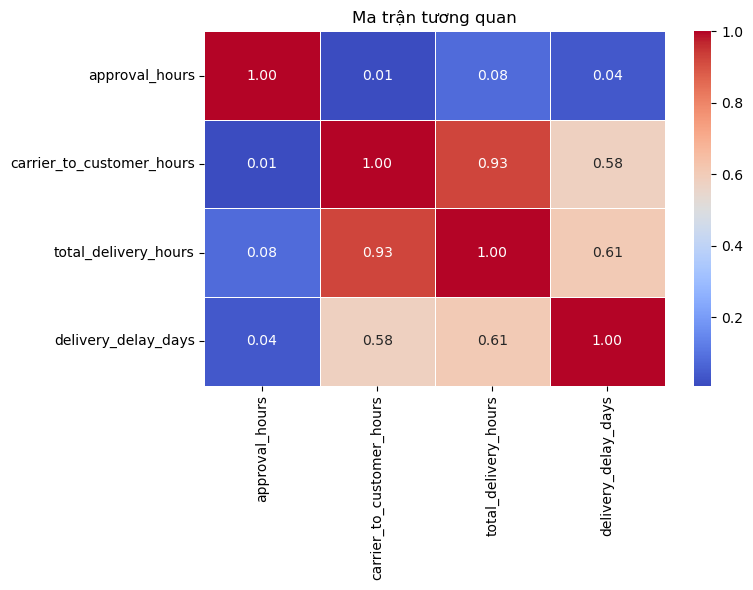

Số lượng outlier (total_delivery_hours > 699.6 giờ): 4896 (5.07%)

Một số outlier điển hình:


,order_id,total_delivery_hours,delivery_delay_days
29,ecab90c9933c58908d3d6add7c6f5ae3,729.645556,-17.0
35,8563039e855156e48fccee4d611a3196,728.994167,0.0
41,6ea2f835b4556291ffdc53fa0b3b95e8,813.526389,7.0
97,6a0a8bfbbe700284feb0845d95e0867f,872.177222,17.0
110,9d531c565e28c3e0d756192f84d8731f,1344.635556,32.0
115,8fc207e94fa91a7649c5a5dab690272a,1315.876667,32.0
252,f31535f21d145b2345e2bf7f09d62322,1952.033333,49.0
297,06ae7271902bbb087fc093137fee6e81,766.330000,-2.0
311,4906eeadde5f70b308c20c4a8f20be02,781.325556,6.0
326,bca3dc20a3ec02261c5b17dc270e9e65,726.373333,-1.0


In [33]:
# Ma trận tương quan và phát hiện ngoại lệ

# Ma trận tương quan giữa các chỉ số
corr_cols = ['approval_hours', 'carrier_to_customer_hours', 'total_delivery_hours', 'delivery_delay_days']
corr_matrix = delivered[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Ma trận tương quan')
plt.tight_layout()
plt.show()
# Phát hiện outlier trong total_delivery_hours bằng IQR
Q1 = delivered['total_delivery_hours'].quantile(0.25)
Q3 = delivered['total_delivery_hours'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
outliers = delivered[delivered['total_delivery_hours'] > upper_bound]
print(f"Số lượng outlier (total_delivery_hours > {upper_bound:.1f} giờ): {len(outliers)} ({len(outliers)/len(delivered)*100:.2f}%)")
print("\nMột số outlier điển hình:")
outliers[['order_id', 'total_delivery_hours', 'delivery_delay_days']].head(10)


### **Nhận xét:**  
#### - `total_delivery_hours` tương quan rất cao với `carrier_to_customer_hours` (0.98).  
#### - `delivery_delay_days` tương quan dương vừa phải với `total_delivery_hours` (0.47).  
#### - Khoảng 2,4% đơn hàng có tổng thời gian giao hàng > 335 giờ (~14 ngày) – cần được xem xét.

##  Kết luận chính
#### 1. **Hiệu suất giao hàng tốt:** 97% đơn hàng thành công, 85% giao sớm hơn dự kiến.  
#### 2. **Thời gian xử lý nhanh:** Phê duyệt trung bình vài giờ, vận chuyển ~5,4 ngày.  
#### 3. **Xu hướng đặt hàng rõ ràng:** Tập trung vào giờ hành chính, ngày trong tuần, cao điểm cuối năm.  
#### 4. **Dự báo thời gian giao hàng có thể tối ưu hơn:** Vì phần lớn giao sớm, có thể rút ngắn thời gian dự kiến để cạnh tranh.  
#### 5. **Tồn tại vấn đề với một số đơn hàng:** Cần điều tra các đơn bị trễ lâu và có thời gian vận chuyển bất thường. 

### **Đề xuất:**  
#### - Cải thiện độ chính xác của ngày giao hàng dự kiến.  
#### - Phân tích sâu các đơn hàng chậm trễ (theo khu vực, nhà cung cấp, phương thức vận chuyển).  
#### - Tự động cảnh báo đơn hàng có trạng thái `shipped` hoặc `processing` quá lâu.
